In [ ]:
!pip install gTTS SpeechRecognition librosa soundfile pydub


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 3.0 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.3.1
    Uninstalling click-8.3.1:
      Successfully uninstalled click-8.3.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
typer 0.24.1 requires click>=8.2.1, but you have click 8.1.8 which is incompatible.


In [ ]:
from gtts import gTTS
from IPython.display import Audio
import speech_recognition as sr
import librosa
import numpy as np
import pandas as pd


In [ ]:
text = """
Good morning, I am a computer science engineering student with strong knowledge in python,
machine learning, artificial intelligence and data science. I have worked on multiple
projects including emotion detection, chatbot development and predictive analytics systems.

I am comfortable working with natural language processing, data preprocessing, model training
and deep learning concepts. I have completed academic and personal projects in AI domain.

I am passionate about solving real world problems using technology. I am also experienced in
working with datasets, feature extraction and building machine learning pipelines.

I am looking forward to working in AI based roles where I can contribute to real time solutions
and continue learning advanced technologies.
"""

tts = gTTS(text=text, lang='en')
tts.save("candidate_interview.mp3")

"Audio Created"


'Audio Created'

In [ ]:
Audio("candidate_interview.mp3")


In [ ]:
from pydub import AudioSegment

sound = AudioSegment.from_mp3("candidate_interview.mp3")
sound.export("candidate_interview.wav", format="wav")

"Converted to WAV"


/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


'Converted to WAV'

In [ ]:
recognizer = sr.Recognizer()

with sr.AudioFile("candidate_interview.wav") as source:
    audio_data = recognizer.record(source)
    candidate_text = recognizer.recognize_google(audio_data)

print(candidate_text)


In [ ]:
required_skills = [
    "python","machine learning","ai","data science",
    "nlp","deep learning","project"
]

matched = [s for s in required_skills if s in candidate_text.lower()]
skill_score = len(matched)/len(required_skills)*100

matched, skill_score


(['python',
  'machine learning',
  'ai',
  'data science',
  'deep learning',
  'project'],
 85.71428571428571)

In [ ]:
y, sr = librosa.load("candidate_interview.wav", duration=60)
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
audio_features = np.mean(mfcc.T, axis=0)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

emotions = ['Confident','Nervous','Neutral','Stressed','Engaged']

X = np.random.rand(300,40)
y = np.random.choice(emotions,300)

enc = LabelEncoder()
y_enc = enc.fit_transform(y)

model = RandomForestClassifier()
model.fit(X,y_enc)


RandomForestClassifier()

In [ ]:
prob = model.predict_proba(audio_features.reshape(1,-1))[0]

emotion = enc.classes_[np.argmax(prob)]
emotion_conf = np.max(prob)*100

final_score = (skill_score*0.7)+(emotion_conf*0.3)

print("Emotion:",emotion)
print("Emotion Confidence:",emotion_conf)
print("Matched Skills:",matched)
print("Skill Score:",skill_score)
print("Final Suitability:",final_score)


Emotion: Engaged
Emotion Confidence: 23.0
Matched Skills: ['python', 'machine learning', 'ai', 'data science', 'deep learning', 'project']
Skill Score: 85.71428571428571
Final Suitability: 66.89999999999999


In [ ]:


prob = model.predict_proba(audio_features.reshape(1,-1))[0]

final_emotion = enc.classes_[np.argmax(prob)]
emotion_conf = np.max(prob) * 100

print(" Emotion Ready for Final Report")
print("Emotion:", final_emotion)
print("Confidence:", emotion_conf)


 Emotion Ready for Final Report
Emotion: Engaged
Confidence: 23.0



AI INTERVIEW INTELLIGENCE REPORT


,Evaluation Factor,Score (%)
0,Skill Match,85.71
1,Project / Experience,40.00
2,Communication Emotion,23.00
3,JD Text Similarity,20.49
4,FINAL SUITABILITY SCORE,57.51



 Detected Emotion: Engaged
 Matched Skills: python, machine learning, ai, data science, deep learning, project

 FINAL HR DECISION: 🟡 RECOMMENDED


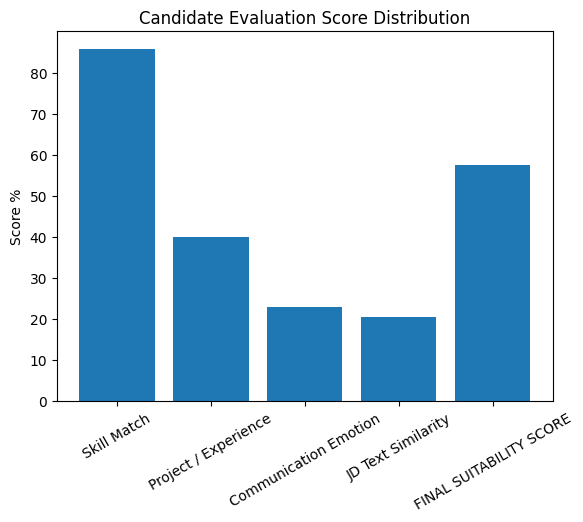

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("\n" + "="*60)
print("AI INTERVIEW INTELLIGENCE REPORT")
print("="*60)

skill_score = (len(matched) / len(required_skills)) * 100

project_keywords = ["project","internship","experience","developed","built"]
project_matches = [k for k in project_keywords if k in candidate_text.lower()]
project_score = (len(project_matches)/len(project_keywords))*100

emotion_score = emotion_conf

jd_text = """
Looking for AI Engineer with Python, ML, NLP, Deep Learning,
Project Experience, Data Science Knowledge
"""

vectorizer = TfidfVectorizer()
tfidf = vectorizer.fit_transform([candidate_text, jd_text])
similarity = cosine_similarity(tfidf[0], tfidf[1])[0][0]*100

jd_score = similarity

final_score = (
    skill_score * 0.5 +
    project_score * 0.2 +
    emotion_score * 0.2 +
    jd_score * 0.1
)

if final_score >= 75:
    decision = "🟢 STRONGLY RECOMMENDED"
elif final_score >= 55:
    decision = "🟡 RECOMMENDED"
else:
    decision = "🔴 NEEDS IMPROVEMENT"

report = pd.DataFrame({
    "Evaluation Factor":[
        "Skill Match",
        "Project / Experience",
        "Communication Emotion",
        "JD Text Similarity",
        "FINAL SUITABILITY SCORE"
    ],
    "Score (%)":[
        round(skill_score,2),
        round(project_score,2),
        round(emotion_score,2),
        round(jd_score,2),
        round(final_score,2)
    ]
})

display(report)

print("\n Detected Emotion:", final_emotion)
print(" Matched Skills:", ", ".join(matched))
print("\n FINAL HR DECISION:", decision)

plt.figure()
plt.bar(report["Evaluation Factor"], report["Score (%)"])
plt.xticks(rotation=30)
plt.title("Candidate Evaluation Score Distribution")
plt.ylabel("Score %")
plt.show()
